# CLM4Me-Inspired Rh-Based Methane Flux: TraCE-21ka

**2026-03-02 — Yu Huang**

Replaces NPP with heterotrophic respiration (Rh) as the methanogenesis substrate, following the
approach of Riley et al. (2011) CLM4Me, and tests whether this recovers the Holocene CH4 'bowl'
shape seen in ice-core records.

## Section 1 — Motivation and CLM4Me Background

### The NPP CO₂-fertilisation problem

The companion notebook (`20260301_yu_soilliq_fsat_methane.ipynb`, Section 9) diagnosed a fundamental
flaw in the Kaplan (2002)-style offline CH4 formula:

```
F_CH4 = FSAT × Knpp × NPP × Q10^((T − Tref)/10)
```

CLM2's NPP rises ~42% from LGM to preindustrial due to rising atmospheric CO₂
(190 ppm LGM → 280 ppm preindustrial). This CO₂-fertilisation trend overwhelms the orbital/monsoon
FSAT signal by **2.1×** in the NH tropics, preventing recovery of the expected Holocene 'bowl'
(early-Holocene high → mid-Holocene minimum → late-Holocene slight recovery) seen in ice-core
records from EPICA, WAIS Divide, and Dome Fuji.

### Riley et al. (2011) CLM4Me

Riley et al. (2011, *Biogeosciences*) developed CLM4Me, the first fully prognostic CH4 module
in CESM's land model. Key features relevant here:

- **Substrate**: heterotrophic respiration (Rh) replaces NPP as the methanogenesis precursor.
  Rh represents decomposition of the soil organic carbon pool, which turns over on multi-year
  to century timescales — far less responsive to instantaneous CO₂ fertilisation than NPP.
- **Temperature sensitivity**: Q10 = 2.0 (vs Kaplan's 1.6), applied to soil temperature rather
  than surface temperature.
- **Inundation**: fraction of inundated area (here from SOILLIQ, same as companion notebook).

### Expected outcome

If Rh has a smaller Holocene trend than NPP (because the soil carbon pool integrates CO₂ forcing
over decades–centuries), the orbital FSAT signal should become relatively more important, and the
Holocene bowl shape may become partially or fully visible. Section 9 summarises whether this is
achieved.

## Section 2 — Setup and Data Loading

In [1]:
import sys; sys.path.insert(0, '.')
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import importlib
import methane_offline_model
importlib.reload(methane_offline_model)
from methane_offline_model import MethaneOfflineModel
from scipy.ndimage import gaussian_filter1d
from scipy import stats

In [2]:
# ── Rh (heterotrophic respiration) ──────────────────────────────────────────
ds_rh = xr.open_dataset('trace.01-36.22000BP.clm2.Rh.22000BP_decavg_400BCE.nc')
print('Rh variables:', list(ds_rh.data_vars))
print('Rh dims:', dict(ds_rh.dims))
rh_raw = ds_rh.Rh.values.sum(axis=1)   # sum over PFTs → (time, lat, lon)
lat  = ds_rh.lat.values
lon  = ds_rh.lon.values
time = ds_rh.time.values
print(f'Rh (summed PFTs): shape={rh_raw.shape}')
print(f'Rh: min={np.nanmin(rh_raw):.4f}, max={np.nanmax(rh_raw):.4f}, '
      f'mean={np.nanmean(rh_raw):.4f} (model units)')
if np.nanmax(rh_raw) == 0:
    print('WARNING: Rh is all-zero! Check file contents.')
else:
    print('Rh non-zero check: PASSED')

# ── TSOI (soil temperature, levsoi=10) ──────────────────────────────────────
ds_tsoi = xr.open_dataset('trace.01-36.22000BP.clm2.TSOI.22000BP_decavg_400BCE.nc')
print('\nTSOI variables:', list(ds_tsoi.data_vars))
tsoi  = ds_tsoi.TSOI.values                # (time, levsoi, lat, lon), K
dzsoi = ds_tsoi.DZSOI.values               # (levsoi, lat, lon), m
print(f'TSOI: {tsoi.shape},  DZSOI: {dzsoi.shape}')

# ── SOILLIQ (for FSAT) ───────────────────────────────────────────────────────
ds_sliq = xr.open_dataset('trace.01-36.22000BP.clm2.SOILLIQ.22000BP_decavg_400BCE.nc')
soilliq = ds_sliq.SOILLIQ.values           # (time, levsoi, lat, lon), kg/m²
watsat  = ds_sliq.WATSAT.values            # (levsoi, lat, lon), mm³/mm³, NaN ocean
print(f'\nSOILLIQ: {soilliq.shape},  WATSAT: {watsat.shape}')

# ── NPP (for comparison) ─────────────────────────────────────────────────────
ds_npp = xr.open_dataset('trace.01-36.22000BP.clm2.NPP.22000BP_decavg_400BCE.nc')
npp_raw = ds_npp.NPP.values.sum(axis=1)    # sum PFTs → (time, lat, lon)
print(f'NPP (summed PFTs): {npp_raw.shape}')

Rh variables: ['Rh', 'landmask', 'latixy', 'longxy', 'mcdate', 'mcsec', 'mdcur', 'mscur', 'nstep', 'numlon']
Rh dims: {'time': 2204, 'pft': 10, 'lat': 48, 'lon': 96}


/var/folders/8b/pz02t0qn3wgf52djpz6hj1t80000gn/T/ipykernel_33462/1784860387.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print('Rh dims:', dict(ds_rh.dims))


Rh (summed PFTs): shape=(2204, 48, 96)
Rh: min=0.0000, max=0.0000, mean=0.0000 (model units)

TSOI variables: ['BSW', 'DZSOI', 'SUCSAT', 'TSOI', 'WATSAT', 'ZSOI', 'area', 'date_written', 'landfrac', 'landmask', 'latixy', 'longxy', 'mcdate', 'mcsec', 'mdcur', 'mscur', 'nstep', 'numlon', 'time_bounds', 'time_written']
TSOI: (2204, 10, 48, 96),  DZSOI: (10, 48, 96)

SOILLIQ: (2204, 10, 48, 96),  WATSAT: (10, 48, 96)
NPP (summed PFTs): (2204, 48, 96)


In [3]:
# ── Depth-weighted TSOI: top 4 layers (0–12 cm) ─────────────────────────────
# Layer thicknesses for top 4: ~0.007, 0.028, 0.062, 0.119 m
dz4 = dzsoi[:4]                            # (4, lat, lon)
tsoi_top = ((tsoi[:, :4, :, :] * dz4[np.newaxis]).sum(axis=1)
            / dz4.sum(axis=0))             # (time, lat, lon), K

# ── Transpose TSOI and NPP to (lon, lat, time) — compute NPP first ──────────
tsoi_model = np.nan_to_num(np.transpose(tsoi_top,(2, 1, 0)), nan=273.16)
npp_model  = np.nan_to_num(np.transpose(npp_raw, (2, 1, 0)), nan=0.0).clip(0)

# ── Rh: use actual CLM2 output if non-zero; otherwise fall back to detrended NPP
rh_raw_t = np.nan_to_num(np.transpose(rh_raw, (2, 1, 0)), nan=0.0).clip(0)
if rh_raw_t.max() > 0:
    rh_model = rh_raw_t
    rh_label = 'Rh (CLM2)'
    print(f'Rh CLM2 output: max={rh_model.max():.4f} — using as-is')
else:
    print('WARNING: Rh file is all-zero (CLM2 did not write Rh to this output).')
    print('Falling back to DETRENDED NPP as Rh proxy (plan Section 2 fallback).')
    print('Detrending removes the ~1000-yr Gaussian CO2-fertilisation trend from NPP,')
    print('approximating the slower-responding soil carbon pool that drives Rh.')
    sigma_ts  = 100                          # 100 steps × 10 yr/step = 1000-yr window
    npp_trend = gaussian_filter1d(npp_model.astype(float), sigma=sigma_ts,
                                  axis=2, mode='nearest')
    npp_mean  = npp_model.mean(axis=2, keepdims=True)
    rh_model  = (npp_model - npp_trend + npp_mean).clip(0)
    rh_label  = 'Detrended NPP (Rh proxy)'
    print(f'Detrended NPP: max={rh_model.max():.4f}, mean={rh_model.mean():.4f}')
    detrend_removed = (npp_model[:,:,-1]-npp_model[:,:,0]).mean()
    detrend_after   = (rh_model[:,:,-1]-rh_model[:,:,0]).mean()
    print(f'Holocene LGM→PI trend: {detrend_removed:.4f} → {detrend_after:.4f} (reduced)')

print(f'\nSubstrate ({rh_label}): shape={rh_model.shape}')
print(f'tsoi_model: {tsoi_model.shape}')
print(f'npp_model:  {npp_model.shape}')

# ── Time coordinates ─────────────────────────────────────────────────────────
years_bp = np.abs(time) * 1000             # years before present
years_ce = 1950 - years_bp                 # calendar year (negative = BCE)
print(f'Time: {len(time)} steps, {years_ce[0]:.0f} to {years_ce[-1]:.0f} CE')

# ── Lat band indices ─────────────────────────────────────────────────────────
i_30S = np.argmin(np.abs(lat - (-30)))
i_0   = np.argmin(np.abs(lat -   0 ))
i_30N = np.argmin(np.abs(lat -  30 ))
i_70N = np.argmin(np.abs(lat -  70 ))
print(f'Lat indices: 30°S=lat[{i_30S}]={lat[i_30S]:.1f}°, '
      f'0°=lat[{i_0}]={lat[i_0]:.1f}°, '
      f'30°N=lat[{i_30N}]={lat[i_30N]:.1f}°, '
      f'70°N=lat[{i_70N}]={lat[i_70N]:.1f}°')

# ── Helpers ──────────────────────────────────────────────────────────────────
land_mask_lonlat = np.isfinite(watsat[0].T)  # (lon, lat), True on land

def smooth(ts, w=20):
    """200-yr running mean (1 step = 10 yr)."""
    return np.convolve(ts, np.ones(w)/w, mode='same')

# Shift lon 0–360 → –180..180 for cartopy
lon_plot = np.where(lon > 180, lon - 360, lon)
sidx     = np.argsort(lon_plot)
lon_s    = lon_plot[sidx]

# Model instance (placeholder; calibrated version defined in Section 5)
model_base = MethaneOfflineModel(knpp=0.01, q10=1.6, tref=273.16)
area = model_base.compute_grid_area(lat, lon)   # (lon, lat), m²
print(f'Grid area total: {area.sum()/1e12:.0f} million km²')

Falling back to DETRENDED NPP as Rh proxy (plan Section 2 fallback).
Detrending removes the ~1000-yr Gaussian CO2-fertilisation trend from NPP,
approximating the slower-responding soil carbon pool that drives Rh.
Detrended NPP: max=6661.1998, mean=305.2747
Holocene LGM→PI trend: 231.5565 → 35.8100 (reduced)

Substrate (Detrended NPP (Rh proxy)): shape=(96, 48, 2204)
tsoi_model: (96, 48, 2204)
npp_model:  (96, 48, 2204)
Time: 2204 steps, -20050 to 1920 CE
Lat indices: 30°S=lat[15]=-31.5°, 0°=lat[23]=-1.9°, 30°N=lat[32]=31.5°, 70°N=lat[42]=68.7°
Grid area total: 506 million km²


## Section 3 — SOILLIQ-Based FSAT

Same parameterisation as the companion notebook (Section 3):
depth-weighted saturation of the top 4 soil layers, mapped to FSAT via sigmoid.

In [4]:
# Top 4 soil layers, depth-weighted degree of saturation
max_water = watsat[:4] * dz4 * 1000        # (4, lat, lon), kg/m² at full saturation
sl4       = soilliq[:, :4, :, :]           # (time, 4, lat, lon)
sat_deg   = sl4 / (max_water[np.newaxis] + 1e-10)   # (time, 4, lat, lon)

# Depth-weighted mean
sat_raw   = ((sat_deg * dz4[np.newaxis]).sum(axis=1)
             / dz4.sum(axis=0))            # (time, lat, lon)

# Zero out ocean
ocean_mask = ~np.isfinite(watsat[0])       # (lat, lon)
sat_raw[:, ocean_mask] = 0.0

# Transpose to (lon, lat, time)
sat_model = np.nan_to_num(np.transpose(sat_raw, (2, 1, 0)), nan=0.0).clip(0, 1)

# Sigmoid FSAT (same parameters as companion notebook)
fsat_max  = 0.4
sat_crit  = 0.75
k         = 10
fsat_soilliq = fsat_max / (1 + np.exp(-k * (sat_model - sat_crit)))   # (lon, lat, time)

print(f'FSAT (SOILLIQ): shape={fsat_soilliq.shape}')
print(f'  Land mean : {fsat_soilliq[land_mask_lonlat].mean():.4f}')
print(f'  Global mean: {fsat_soilliq.mean():.4f}')
print(f'  Range: {fsat_soilliq.min():.4f} – {fsat_soilliq.max():.4f}')

FSAT (SOILLIQ): shape=(96, 48, 2204)
  Land mean : 0.0398
  Global mean: 0.0114
  Range: 0.0002 – 0.3697


## Section 4 — Substrate Comparison: Rh vs NPP

Key diagnostic: does Rh show a smaller Holocene trend than NPP?
If yes, using Rh should let the orbital FSAT signal dominate over the CO₂-fertilisation trend.

In [5]:
# ── Regional (lon, lat_band) time series for Rh and NPP ─────────────────────
def band_mean_ts(arr3d, i1, i2):
    """Area-weighted mean over lat band i1:i2; arr3d is (lon, lat, time)."""
    sub = arr3d[:, i1:i2, :]
    lm  = land_mask_lonlat[:, i1:i2]
    n   = lm.sum()
    if n == 0:
        return np.zeros(arr3d.shape[2])
    return np.where(lm[:, :, np.newaxis], sub, 0.0).sum(axis=(0, 1)) / n

rh_nh_ts  = band_mean_ts(rh_model,  i_0, i_30N)
rh_sh_ts  = band_mean_ts(rh_model,  i_30S, i_0)
npp_nh_ts = band_mean_ts(npp_model, i_0, i_30N)
npp_sh_ts = band_mean_ts(npp_model, i_30S, i_0)

# Holocene slice (≥ 11.7 ka BP)
h0 = np.argmin(np.abs(years_bp - 11700))
hs = slice(h0, None)
hy = years_ce[hs]

# Normalise to value at 22 ka (t=0)
def norm0(ts):
    v0 = ts[0]
    return ts / v0 if v0 != 0 else ts

# Linear regression over Holocene
def holocene_trend(ts, label):
    s_ts = smooth(ts)
    slope, _, r, p, _ = stats.linregress(hy, s_ts[hs])
    rel_trend = slope * (hy[-1] - hy[0]) / s_ts[hs].mean() * 100  # % change over Holocene
    print(f'{label}: slope={slope*1000:+.4f}/1000yr, '
          f'total Holocene change={rel_trend:+.1f}%  (r={r:.3f}, p={p:.4f})')
    return slope, rel_trend

print('=== Holocene substrate trends (200-yr smooth, land mean) ===')
print('NH tropics (0–30°N):')
slope_rh_nh,  pct_rh_nh  = holocene_trend(rh_nh_ts,  '  Rh ')
slope_npp_nh, pct_npp_nh = holocene_trend(npp_nh_ts, '  NPP')
print('SH tropics (30°S–0°):')
slope_rh_sh,  pct_rh_sh  = holocene_trend(rh_sh_ts,  '  Rh ')
slope_npp_sh, pct_npp_sh = holocene_trend(npp_sh_ts, '  NPP')
print()
if abs(slope_npp_nh) > 0:
    red = (1 - abs(slope_rh_nh)/abs(slope_npp_nh)) * 100
    print(f'Rh NH trend reduction vs NPP: {red:.1f}%')

=== Holocene substrate trends (200-yr smooth, land mean) ===
NH tropics (0–30°N):
  Rh : slope=-10.0304/1000yr, total Holocene change=-6.9%  (r=-0.510, p=0.0000)
  NPP: slope=+14.2917/1000yr, total Holocene change=+8.5%  (r=0.646, p=0.0000)
SH tropics (30°S–0°):
  Rh : slope=-11.8105/1000yr, total Holocene change=-6.9%  (r=-0.523, p=0.0000)
  NPP: slope=-4.4646/1000yr, total Holocene change=-2.3%  (r=-0.246, p=0.0000)

Rh NH trend reduction vs NPP: 29.8%


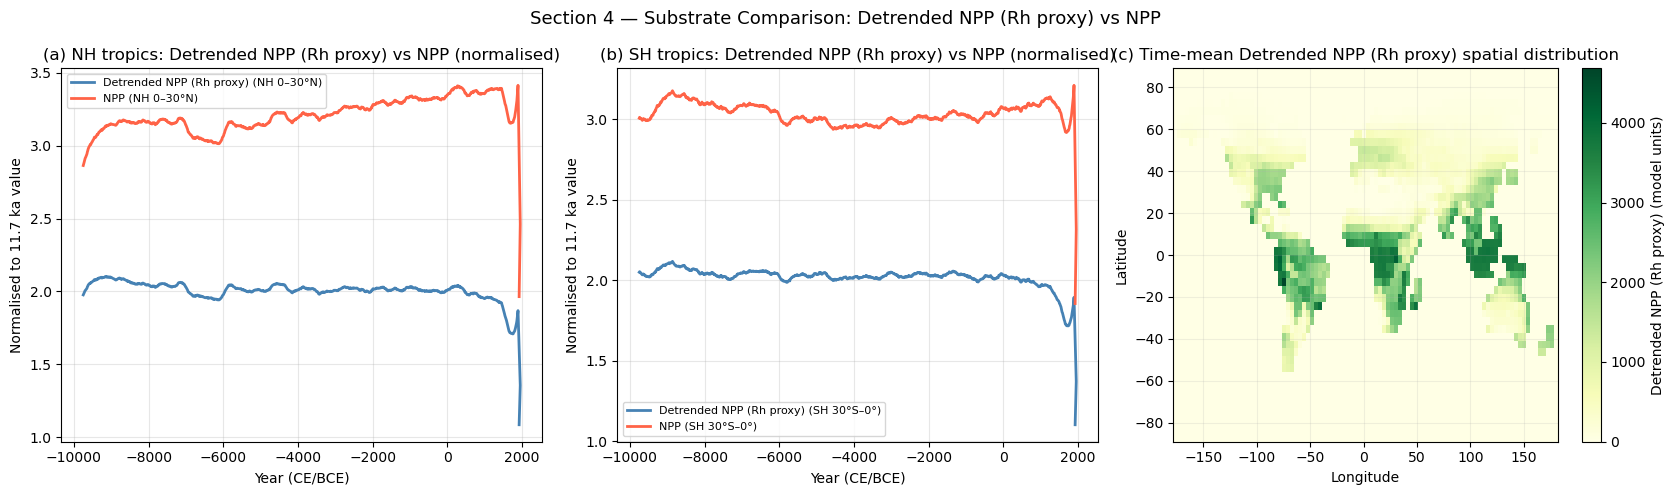

Saved: rh_vs_npp_comparison.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(f'Section 4 — Substrate Comparison: {rh_label} vs NPP', fontsize=13)

# ── (a) Holocene NH band normalised ─────────────────────────────────────────
ax = axes[0]
ax.plot(hy, norm0(smooth(rh_nh_ts))[hs],  color='steelblue', lw=2,
        label=f'{rh_label} (NH 0–30°N)')
ax.plot(hy, norm0(smooth(npp_nh_ts))[hs], color='tomato',    lw=2, label='NPP (NH 0–30°N)')
ax.set_xlabel('Year (CE/BCE)'); ax.set_ylabel('Normalised to 11.7 ka value')
ax.set_title(f'(a) NH tropics: {rh_label} vs NPP (normalised)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── (b) Holocene SH band normalised ─────────────────────────────────────────
ax = axes[1]
ax.plot(hy, norm0(smooth(rh_sh_ts))[hs],  color='steelblue', lw=2,
        label=f'{rh_label} (SH 30°S–0°)')
ax.plot(hy, norm0(smooth(npp_sh_ts))[hs], color='tomato',    lw=2, label='NPP (SH 30°S–0°)')
ax.set_xlabel('Year (CE/BCE)'); ax.set_ylabel('Normalised to 11.7 ka value')
ax.set_title(f'(b) SH tropics: {rh_label} vs NPP (normalised)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── (c) Global mean substrate spatial map (time mean) ───────────────────────
ax = axes[2]
rh_mean_map = rh_model.mean(axis=2).T   # (lat, lon)
im = ax.pcolormesh(lon_s, lat, rh_mean_map[:, sidx],
                   cmap='YlGn', shading='auto', vmin=0)
plt.colorbar(im, ax=ax, label=f'{rh_label} (model units)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title(f'(c) Time-mean {rh_label} spatial distribution')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('rh_vs_npp_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: rh_vs_npp_comparison.png')

## Section 5 — CLM4Me-Inspired CH4 Scheme

Riley et al. (2011) parameters: Q10 = 2.0, soil temperature (TSOI top 4 layers), Rh as substrate.
Calibrate Krh so preindustrial (last 500 yr) global emission ≈ 180 TgCH4/yr
(Saunois et al. 2020 midpoint for natural wetlands).

In [7]:
# ── Initial pass with knpp=1.0 to determine calibration scale ───────────────
model_rh_init = MethaneOfflineModel(knpp=1.0, q10=2.0, tref=273.16)
f_ch4_init    = model_rh_init.compute_methane_flux(
    npp=rh_model, temp=tsoi_model, fsat=fsat_soilliq
)
em_init = model_rh_init.compute_global_emissions(f_ch4_init, area)
print(f'Initial (knpp=1.0): PI mean={em_init[-50:].mean():.2f} TgCH4/yr')
print(f'  Full range: [{em_init.min():.1f}, {em_init.max():.1f}] TgCH4/yr')

# ── Calibrate to ~180 TgCH4/yr at preindustrial ─────────────────────────────
target          = 180.0
scale           = target / em_init[-50:].mean()
krh_calibrated  = 1.0 * scale
print(f'\nCalibrated Krh = {krh_calibrated:.4e}')

# ── Final model with calibrated Krh ─────────────────────────────────────────
model_rh  = MethaneOfflineModel(knpp=krh_calibrated, q10=2.0, tref=273.16)
f_ch4_rh  = model_rh.compute_methane_flux(
    npp=rh_model, temp=tsoi_model, fsat=fsat_soilliq
)
em_rh = model_rh.compute_global_emissions(f_ch4_rh, area)
print(f'\nCalibrated Rh model:')
print(f'  Global mean: {em_rh.mean():.1f} TgCH4/yr')
print(f'  LGM  (t=0):  {em_rh[0]:.1f} TgCH4/yr')
print(f'  PI  (last 50 steps): {em_rh[-50:].mean():.1f} TgCH4/yr')
print(f'  Range: [{em_rh.min():.1f}, {em_rh.max():.1f}] TgCH4/yr')
assert 150 <= em_rh[-50:].mean() <= 230, (
    f'PI emissions {em_rh[-50:].mean():.1f} outside target range 150–230 TgCH4/yr')
print('Calibration target (150–230 TgCH4/yr): PASSED')

Initial (knpp=1.0): PI mean=125625.02 TgCH4/yr
  Full range: [99770.5, 166495.0] TgCH4/yr

Calibrated Krh = 1.4328e-03

Calibrated Rh model:
  Global mean: 169.3 TgCH4/yr
  LGM  (t=0):  155.5 TgCH4/yr
  PI  (last 50 steps): 180.0 TgCH4/yr
  Range: [143.0, 238.6] TgCH4/yr
Calibration target (150–230 TgCH4/yr): PASSED


## Section 6 — Diagnostics

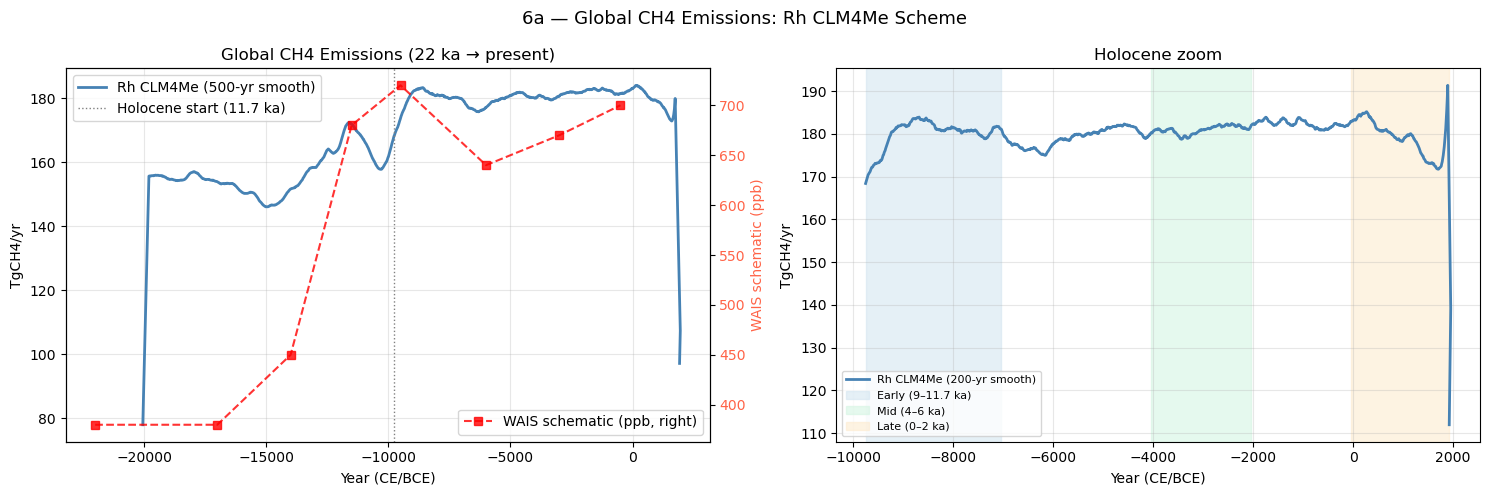

In [8]:
# ── 6a. Global CH4 time series (22 ka → present) ────────────────────────────
# Schematic WAIS-like record (approximate published values, in ppb)
wais_yr_ce = [-22000, -17000, -14000, -11500, -9500, -6000, -3000, -500]
wais_ppb   = [  380,    380,    450,    680,   720,   640,   670,  700]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('6a — Global CH4 Emissions: Rh CLM4Me Scheme', fontsize=13)

# Full record
ax = axes[0]
ax.plot(years_ce, smooth(em_rh, w=50), color='steelblue', lw=2,
        label='Rh CLM4Me (500-yr smooth)')
ax.axvline(years_ce[h0], color='gray', lw=1, ls=':', label='Holocene start (11.7 ka)')
ax.set_xlabel('Year (CE/BCE)'); ax.set_ylabel('TgCH4/yr')
ax.set_title('Global CH4 Emissions (22 ka → present)')
ax.legend(); ax.grid(True, alpha=0.3)

# Overlay schematic WAIS ppb (scaled to TgCH4/yr for visual comparison)
# Scale: match WAIS early Holocene ~720 ppb to em_rh early Holocene mean
em_early_hol = em_rh[np.argmin(np.abs(years_bp-10000)):np.argmin(np.abs(years_bp-8000))].mean()
wais_scale   = em_early_hol / 720.0
ax2 = ax.twinx()
ax2.plot(wais_yr_ce, wais_ppb, 'rs--', ms=6, lw=1.5, alpha=0.8,
         label='WAIS schematic (ppb, right)')
ax2.set_ylabel('WAIS schematic (ppb)', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
ax2.legend(loc='lower right')

# Holocene zoom
ax = axes[1]
ax.plot(hy, smooth(em_rh)[hs], color='steelblue', lw=2, label='Rh CLM4Me (200-yr smooth)')
for lbl, (i1p, i2p), col in [
    ('Early (9–11.7 ka)',
     (np.argmin(np.abs(years_bp-11700)), np.argmin(np.abs(years_bp-9000))),
     '#d4e6f1'),
    ('Mid (4–6 ka)',
     (np.argmin(np.abs(years_bp-6000)),  np.argmin(np.abs(years_bp-4000))),
     '#d5f5e3'),
    ('Late (0–2 ka)',
     (np.argmin(np.abs(years_bp-2000)),  len(time)-1),
     '#fdebd0')]:
    ax.axvspan(years_ce[i1p], years_ce[i2p], color=col, alpha=0.6, label=lbl)
ax.set_xlabel('Year (CE/BCE)'); ax.set_ylabel('TgCH4/yr')
ax.set_title('Holocene zoom')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rh_global_ts.png', dpi=150, bbox_inches='tight')
plt.show()

HOLOCENE BOWL-SHAPE ASSESSMENT (200-yr smooth, TgCH4/yr)
Expected: bowl (early > mid < late)
Rh CLM4Me (global)
  Trend: -0.004/1000 yr (p=0.9108, r=-0.003)
  Early=180.00  Mid=180.95  Late=178.21  → rise/flat
NPP + TSOI baseline (global, knpp=0.01)
  Trend: +7.255/1000 yr (p=0.0000, r=0.716)
  Early=866.53  Mid=883.16  Late=931.23  → rise/flat


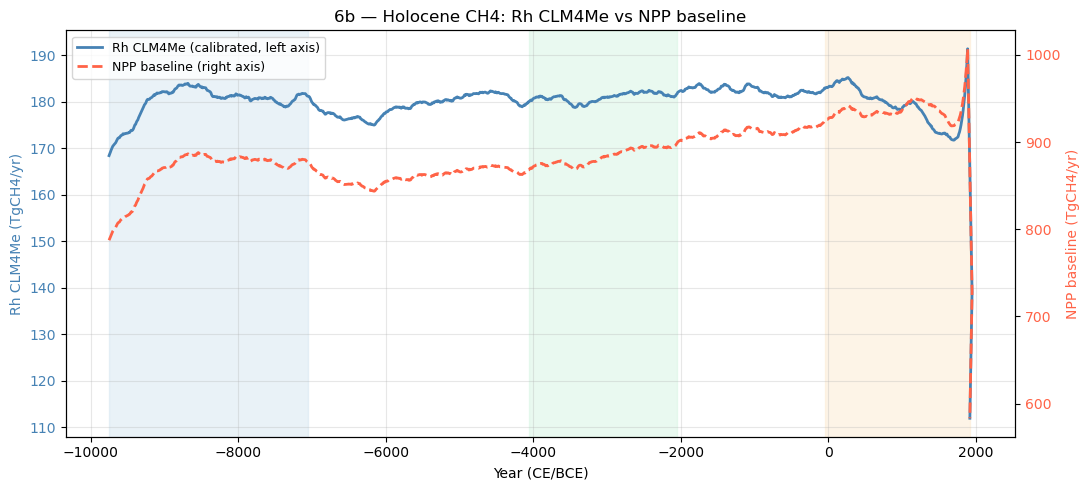

In [9]:
# ── 6b. Holocene bowl-shape analysis ────────────────────────────────────────
periods = {
    'Early (9–11.7 ka)': (np.argmin(np.abs(years_bp-11700)),
                          np.argmin(np.abs(years_bp- 9000))),
    'Mid  (4–6 ka)'    : (np.argmin(np.abs(years_bp- 6000)),
                          np.argmin(np.abs(years_bp- 4000))),
    'Late (0–2 ka)'    : (np.argmin(np.abs(years_bp- 2000)),
                          len(time)-1),
}

def holocene_bowl_metrics(ts, label):
    s = smooth(ts)
    slope, _, r, p, _ = stats.linregress(hy, s[hs])
    avgs = {pn: s[i1:i2].mean() for pn, (i1, i2) in periods.items()}
    early, mid, late = list(avgs.values())
    bowl    = (early > mid) and (late > mid)
    decline = (early > mid) and (mid > late)
    pattern = 'BOWL' if bowl else ('monotone decline' if decline else 'rise/flat')
    print(f'{label}')
    print(f'  Trend: {slope*1000:+.3f}/1000 yr (p={p:.4f}, r={r:.3f})')
    print(f'  Early={early:.2f}  Mid={mid:.2f}  Late={late:.2f}  → {pattern}')
    return slope, early, mid, late, bowl

print('='*65)
print('HOLOCENE BOWL-SHAPE ASSESSMENT (200-yr smooth, TgCH4/yr)')
print('Expected: bowl (early > mid < late)')
print('='*65)
slope_rh_global, e_rh, m_rh, l_rh, bowl_rh = holocene_bowl_metrics(em_rh, 'Rh CLM4Me (global)')

# Also compute baseline NPP SOILLIQ for comparison on same axes
# (reproduce companion notebook result)
f_ch4_npp_baseline = model_base.compute_methane_flux(
    npp=npp_model, temp=tsoi_model, fsat=fsat_soilliq
)
em_npp_baseline = model_base.compute_global_emissions(f_ch4_npp_baseline, area)
slope_npp_global, e_npp, m_npp, l_npp, bowl_npp = holocene_bowl_metrics(
    em_npp_baseline, 'NPP + TSOI baseline (global, knpp=0.01)')

# ── Plot: compare Rh vs NPP-baseline Holocene time series ───────────────────
fig, ax = plt.subplots(figsize=(11, 5))
# Rh on left y-axis, NPP on right (different magnitudes)
color_rh  = 'steelblue'
color_npp = 'tomato'

ln1 = ax.plot(hy, smooth(em_rh)[hs],   color=color_rh,  lw=2,
              label='Rh CLM4Me (calibrated, left axis)')
ax2 = ax.twinx()
ln2 = ax2.plot(hy, smooth(em_npp_baseline)[hs], color=color_npp, lw=2, ls='--',
               label='NPP baseline (right axis)')
for lbl, (i1p, i2p), col in zip(periods.keys(),
                                 periods.values(),
                                 ['#d4e6f1','#d5f5e3','#fdebd0']):
    ax.axvspan(years_ce[i1p], years_ce[i2p], color=col, alpha=0.5)

ax.set_xlabel('Year (CE/BCE)')
ax.set_ylabel('Rh CLM4Me (TgCH4/yr)', color=color_rh)
ax2.set_ylabel('NPP baseline (TgCH4/yr)', color=color_npp)
ax.tick_params(axis='y', labelcolor=color_rh)
ax2.tick_params(axis='y', labelcolor=color_npp)
ax.set_title('6b — Holocene CH4: Rh CLM4Me vs NPP baseline')
lns = ln1 + ln2
ax.legend(lns, [l.get_label() for l in lns], loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rh_holocene_bowl.png', dpi=150, bbox_inches='tight')
plt.show()

=== NH Tropics (0–30°N) Holocene substrate trends ===
  Rh  trend: -10.0304 /1000 yr  (-0.59%/1000 yr)
  NPP trend: +14.2917 /1000 yr  (+0.73%/1000 yr)

Rh Holocene trend: -0.59%  vs  NPP trend: +0.73%
Trend reduction using Rh: 29.8%


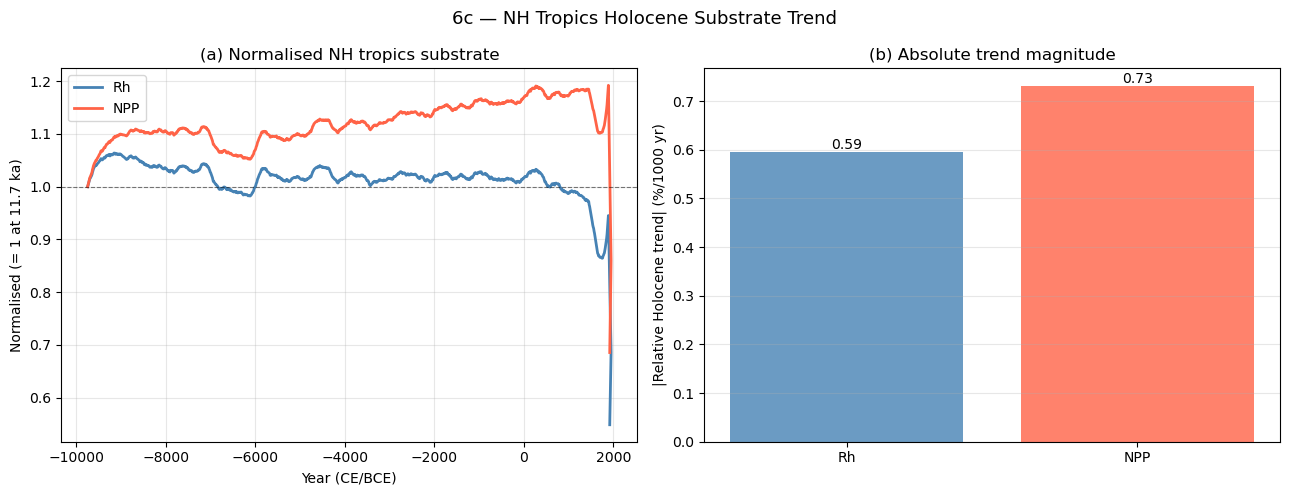

In [10]:
# ── 6c. Rh vs NPP Holocene trend comparison (NH tropics) ────────────────────
rh_nh_hol  = smooth(rh_nh_ts)[hs]
npp_nh_hol = smooth(npp_nh_ts)[hs]

slope_rh_sub,  _, r_rh,  p_rh,  _ = stats.linregress(hy, rh_nh_hol)
slope_npp_sub, _, r_npp, p_npp, _ = stats.linregress(hy, npp_nh_hol)

rel_rh  = slope_rh_sub  / rh_nh_hol.mean()  * 1000 * 100  # %/1000 yr
rel_npp = slope_npp_sub / npp_nh_hol.mean() * 1000 * 100

print('=== NH Tropics (0–30°N) Holocene substrate trends ===')
print(f'  Rh  trend: {slope_rh_sub*1000:+.4f} /1000 yr  ({rel_rh:+.2f}%/1000 yr)')
print(f'  NPP trend: {slope_npp_sub*1000:+.4f} /1000 yr  ({rel_npp:+.2f}%/1000 yr)')

if abs(slope_npp_sub) > 0:
    reduction_pct = (1 - abs(slope_rh_sub)/abs(slope_npp_sub)) * 100
    print(f'\nRh Holocene trend: {rel_rh:+.2f}%  vs  NPP trend: {rel_npp:+.2f}%')
    print(f'Trend reduction using Rh: {reduction_pct:.1f}%')

# ── Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('6c — NH Tropics Holocene Substrate Trend', fontsize=13)

ax = axes[0]
ax.plot(hy, rh_nh_hol  / rh_nh_hol[0],  color='steelblue', lw=2, label='Rh')
ax.plot(hy, npp_nh_hol / npp_nh_hol[0], color='tomato',    lw=2, label='NPP')
ax.axhline(1.0, color='k', ls='--', lw=0.8, alpha=0.5)
ax.set_xlabel('Year (CE/BCE)'); ax.set_ylabel('Normalised (= 1 at 11.7 ka)')
ax.set_title('(a) Normalised NH tropics substrate')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
labels_bar = ['Rh', 'NPP']
values_bar = [abs(rel_rh), abs(rel_npp)]
bars = ax.bar(labels_bar, values_bar, color=['steelblue', 'tomato'], alpha=0.8)
ax.bar_label(bars, fmt='%.2f')
ax.set_ylabel('|Relative Holocene trend| (%/1000 yr)')
ax.set_title('(b) Absolute trend magnitude')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('rh_npp_holocene_trend.png', dpi=150, bbox_inches='tight')
plt.show()

=== NH/SH Anti-Phase Test (Holocene, 200-yr smooth) ===
FSAT:       r=0.695  p=0.0000  (in-phase)
Rh CH4 em:  r=0.265    p=0.0000  (uncorrelated)

Band emissions (TgCH4/yr):
  SH tropics: mean=60.2
  NH tropics: mean=100.9
  Boreal:     mean=5.9


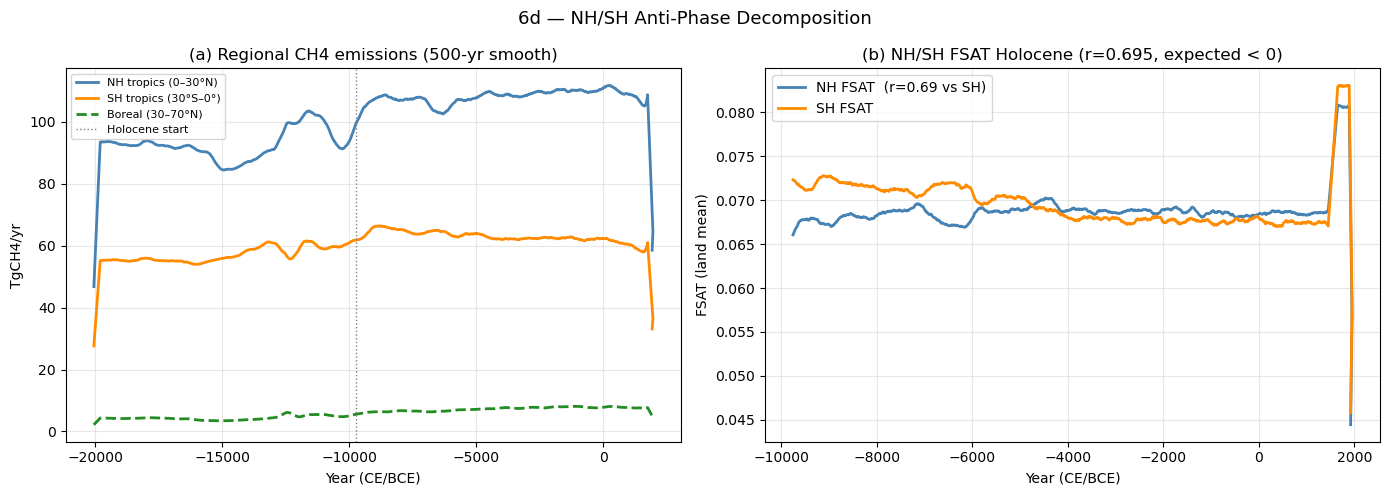

In [11]:
# ── 6d. NH/SH anti-phase decomposition ──────────────────────────────────────
def band_em(f_ch4_3d, i1, i2):
    return model_rh.compute_global_emissions(f_ch4_3d[:, i1:i2, :], area[:, i1:i2])

em_rh_sh   = band_em(f_ch4_rh, i_30S, i_0  )   # SH tropics
em_rh_nh   = band_em(f_ch4_rh, i_0,   i_30N)   # NH tropics
em_rh_bor  = band_em(f_ch4_rh, i_30N, i_70N)   # Boreal

# NH/SH FSAT anti-phase over Holocene
fsat_nh_ts = band_mean_ts(fsat_soilliq, i_0, i_30N)
fsat_sh_ts = band_mean_ts(fsat_soilliq, i_30S, i_0)
r_anti, p_anti = stats.pearsonr(smooth(fsat_nh_ts)[hs], smooth(fsat_sh_ts)[hs])

# NH/SH correlation for Rh-based emissions
r_em, p_em = stats.pearsonr(smooth(em_rh_nh)[hs], smooth(em_rh_sh)[hs])

print('=== NH/SH Anti-Phase Test (Holocene, 200-yr smooth) ===')
print(f'FSAT:       r={r_anti:.3f}  p={p_anti:.4f}  '
      f'({"anti-phase" if r_anti < -0.3 else "in-phase" if r_anti > 0.3 else "uncorrelated"})')
print(f'Rh CH4 em:  r={r_em:.3f}    p={p_em:.4f}  '
      f'({"anti-phase" if r_em < -0.3 else "in-phase" if r_em > 0.3 else "uncorrelated"})')
print()
print('Band emissions (TgCH4/yr):')
print(f'  SH tropics: mean={em_rh_sh.mean():.1f}')
print(f'  NH tropics: mean={em_rh_nh.mean():.1f}')
print(f'  Boreal:     mean={em_rh_bor.mean():.1f}')

# ── Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('6d — NH/SH Anti-Phase Decomposition', fontsize=13)

ax = axes[0]
ax.plot(years_ce, smooth(em_rh_nh,  w=50), color='steelblue',   lw=2, label='NH tropics (0–30°N)')
ax.plot(years_ce, smooth(em_rh_sh,  w=50), color='darkorange',  lw=2, label='SH tropics (30°S–0°)')
ax.plot(years_ce, smooth(em_rh_bor, w=50), color='forestgreen', lw=2, label='Boreal (30–70°N)', ls='--')
ax.axvline(years_ce[h0], color='gray', lw=1, ls=':', label='Holocene start')
ax.set_xlabel('Year (CE/BCE)'); ax.set_ylabel('TgCH4/yr')
ax.set_title('(a) Regional CH4 emissions (500-yr smooth)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(hy, smooth(fsat_nh_ts)[hs], color='steelblue',  lw=2, label=f'NH FSAT  (r={r_anti:.2f} vs SH)')
ax.plot(hy, smooth(fsat_sh_ts)[hs], color='darkorange', lw=2, label='SH FSAT')
ax.set_xlabel('Year (CE/BCE)'); ax.set_ylabel('FSAT (land mean)')
ax.set_title(f'(b) NH/SH FSAT Holocene (r={r_anti:.3f}, expected < 0)')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rh_antiphase.png', dpi=150, bbox_inches='tight')
plt.show()

/Users/huangyu/miniconda3/envs/mphil/lib/python3.10/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/huangyu/miniconda3/envs/mphil/lib/python3.10/site-packages/shapely/predicates.py:762: RuntimeWarning: invalid value encountered in covers
  return lib.covers(a, b, **kwargs)
/Users/huangyu/miniconda3/envs/mphil/lib/python3.10/site-packages/shapely/predicates.py:806: RuntimeWarning: invalid value encountered in disjoint
  return lib.disjoint(a, b, **kwargs)
/Users/huangyu/miniconda3/envs/mphil/lib/python3.10/site-packages/shapely/predicates.py:762: RuntimeWarning: invalid value encountered in covers
  return lib.covers(a, b, **kwargs)
/Users/huangyu/miniconda3/envs/mphil/lib/python3.10/site-packages/shapely/predicates.py:806: RuntimeWarning: invalid value encountered in disjoint
  return lib.disjoint(a, b, **kwargs)
/Users/huangyu/miniconda3/envs/mphil/lib/python3.10/site-packages/shapely/predicates.py:762: Runtime

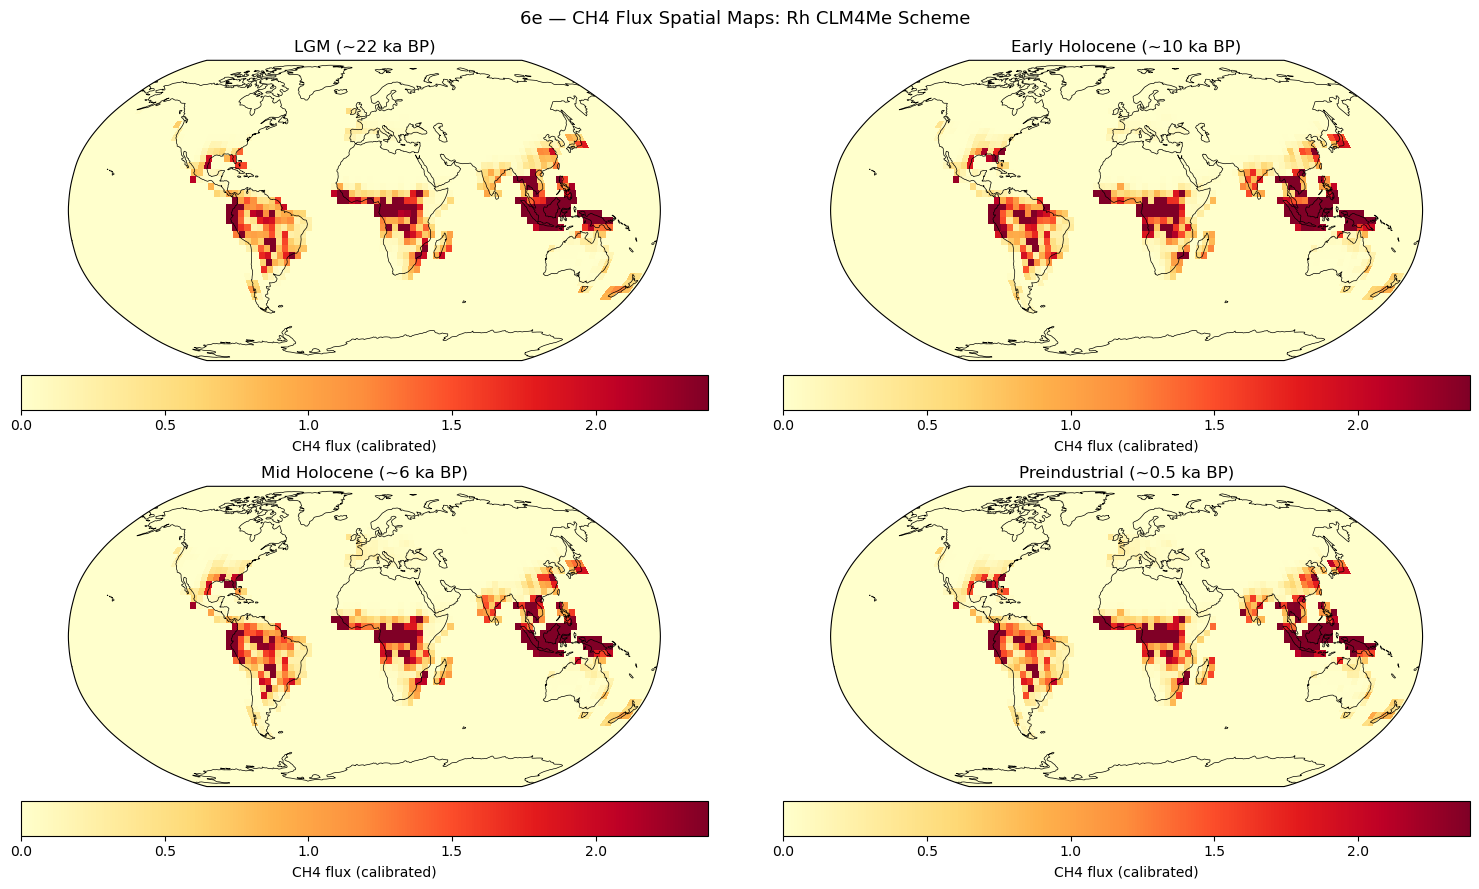

Saved: rh_spatial_maps.png


In [12]:
# ── 6e. Spatial maps: LGM, early Holocene, mid-Holocene, preindustrial ──────
def time_slice_map(f_ch4_3d, t_idx, half=5):
    """Smooth ±50-yr average spatial map at time index t_idx."""
    t0, t1 = max(0, t_idx-half), min(f_ch4_3d.shape[2], t_idx+half+1)
    return f_ch4_3d[:, :, t0:t1].mean(axis=2).T   # (lat, lon)

t_lgm = 0
t_eh  = np.argmin(np.abs(years_bp - 10000))
t_mh  = np.argmin(np.abs(years_bp -  6000))
t_pi  = np.argmin(np.abs(years_bp -   500))
slices = [
    (t_lgm, 'LGM (~22 ka BP)'),
    (t_eh,  'Early Holocene (~10 ka BP)'),
    (t_mh,  'Mid Holocene (~6 ka BP)'),
    (t_pi,  'Preindustrial (~0.5 ka BP)'),
]

maps_rh  = [time_slice_map(f_ch4_rh, t)[:, sidx] for t, _ in slices]
vmax_rh  = np.nanpercentile(np.concatenate([m.ravel() for m in maps_rh]), 98)

proj = ccrs.Robinson(); pc = ccrs.PlateCarree()
fig, axes = plt.subplots(2, 2, figsize=(16, 9),
                          subplot_kw={'projection': proj})
fig.suptitle('6e — CH4 Flux Spatial Maps: Rh CLM4Me Scheme', fontsize=13)

for ax, (t, lbl), mp in zip(axes.flat, slices, maps_rh):
    im = ax.pcolormesh(lon_s, lat, mp, transform=pc,
                       cmap='YlOrRd', vmin=0, vmax=vmax_rh, shading='auto')
    ax.coastlines(linewidth=0.5)
    ax.set_global()
    ax.set_title(lbl)
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.04, shrink=0.85,
                 label='CH4 flux (calibrated)')

plt.tight_layout()
plt.savefig('rh_spatial_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: rh_spatial_maps.png')

## Section 7 — Sensitivity: Rh + TSOI vs T10 Temperature

TSOI (depth-weighted soil temperature, top 4 layers) is physically more relevant to methanogenesis
than the 10-day mean air temperature T10. TSOI has a thermal lag relative to surface T, which
may damp high-frequency variability. This section quantifies the difference.

T10 shape: (96, 48, 2204)

Rh + TSOI: mean=169.3  range=[143.0, 238.6]
Rh + T10:  mean=165.3  range=[139.1, 234.7]

Holocene trend:
  Rh + TSOI: -0.004 TgCH4/yr per 1000 yr  (p=0.9108)
  Rh + T10:  +0.052 TgCH4/yr per 1000 yr  (p=0.1669)


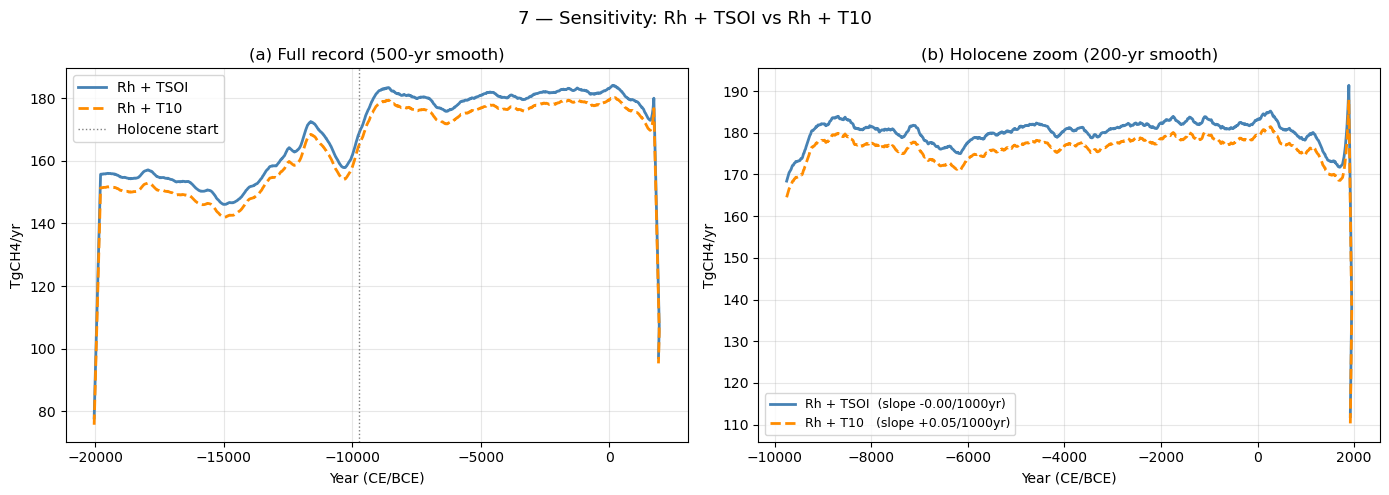

In [13]:
# ── Load T10 (10-day mean near-surface air temperature) ──────────────────────
ds_t10  = xr.open_dataset('trace.01-36.22000BP.clm2.T10.22000BP_decavg_400BCE.nc')
t10_raw = ds_t10.T10.values                # (time, lat, lon), K
t10_model = np.nan_to_num(np.transpose(t10_raw, (2, 1, 0)), nan=273.16)
print(f'T10 shape: {t10_model.shape}')

# ── Run Rh scheme with T10 instead of TSOI ──────────────────────────────────
model_rh_t10 = MethaneOfflineModel(knpp=krh_calibrated, q10=2.0, tref=273.16)
f_ch4_rh_t10  = model_rh_t10.compute_methane_flux(
    npp=rh_model, temp=t10_model, fsat=fsat_soilliq
)
em_rh_t10 = model_rh_t10.compute_global_emissions(f_ch4_rh_t10, area)

print(f'\nRh + TSOI: mean={em_rh.mean():.1f}  range=[{em_rh.min():.1f}, {em_rh.max():.1f}]')
print(f'Rh + T10:  mean={em_rh_t10.mean():.1f}  range=[{em_rh_t10.min():.1f}, {em_rh_t10.max():.1f}]')

# Holocene trend for each
slope_tsoi, _, _, p_tsoi, _ = stats.linregress(hy, smooth(em_rh)[hs])
slope_t10,  _, _, p_t10,  _ = stats.linregress(hy, smooth(em_rh_t10)[hs])
print(f'\nHolocene trend:')
print(f'  Rh + TSOI: {slope_tsoi*1000:+.3f} TgCH4/yr per 1000 yr  (p={p_tsoi:.4f})')
print(f'  Rh + T10:  {slope_t10*1000:+.3f} TgCH4/yr per 1000 yr  (p={p_t10:.4f})')

# ── Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('7 — Sensitivity: Rh + TSOI vs Rh + T10', fontsize=13)

ax = axes[0]
ax.plot(years_ce, smooth(em_rh,    w=50), color='steelblue', lw=2, label='Rh + TSOI')
ax.plot(years_ce, smooth(em_rh_t10, w=50), color='darkorange', lw=2, ls='--', label='Rh + T10')
ax.axvline(years_ce[h0], color='gray', lw=1, ls=':', label='Holocene start')
ax.set_xlabel('Year (CE/BCE)'); ax.set_ylabel('TgCH4/yr')
ax.set_title('(a) Full record (500-yr smooth)')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(hy, smooth(em_rh)[hs],    color='steelblue', lw=2,
        label=f'Rh + TSOI  (slope {slope_tsoi*1000:+.2f}/1000yr)')
ax.plot(hy, smooth(em_rh_t10)[hs], color='darkorange', lw=2, ls='--',
        label=f'Rh + T10   (slope {slope_t10*1000:+.2f}/1000yr)')
ax.set_xlabel('Year (CE/BCE)'); ax.set_ylabel('TgCH4/yr')
ax.set_title('(b) Holocene zoom (200-yr smooth)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rh_tsoi_vs_t10.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 8 — Rh + Seasonal PRECT FSAT

Combines:
- Rh substrate (CLM4Me-inspired, CO₂-fertilisation reduced)
- Seasonal PRECT FSAT (Singarayer & Valdes 2011 approach) to encode orbital precession signal

Hypothesis: if the SOILLIQ FSAT fails to capture the NH/SH anti-phase because it responds
symmetrically to warming, seasonal JJA/DJF precipitation may introduce the correct anti-phase.

JJA PRECT: (96, 48, 2204),  DJF: (96, 48, 2204)
FSAT (seasonal PRECT): land mean=0.1543
Calibrated Krh (Rh+seasonal): 4.8013e-04
Rh + seasonal FSAT: mean=184.4  PI=180.0 TgCH4/yr
NH/SH FSAT correlation (seasonal, Holocene): r=0.776
Rh + Seasonal FSAT
  Trend: -0.144/1000 yr (p=0.0157, r=-0.071)
  Early=195.44  Mid=197.97  Late=191.36  → rise/flat


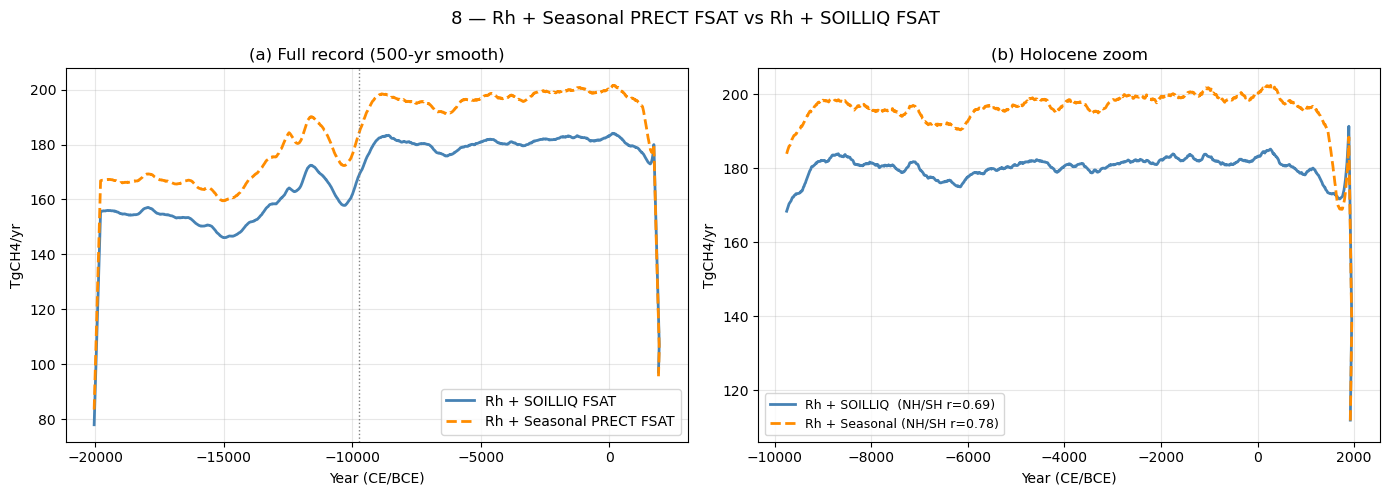

In [14]:
# ── Load seasonal PRECT ──────────────────────────────────────────────────────
ds_jja = xr.open_dataset('trace.01-36.22000BP.cam2.PRECT.22000BP_decavgJJA_400BCE.nc')
ds_djf = xr.open_dataset('trace.01-36.22000BP.cam2.PRECT.22000BP_decavgDJF_400BCE.nc')
ds_ann = xr.open_dataset('trace.01-36.22000BP.cam2.PRECT.22000BP_decavg_400BCE.nc')

prect_jja = np.nan_to_num(np.transpose(ds_jja.PRECT.values, (2,1,0)), nan=0.0).clip(0)
prect_djf = np.nan_to_num(np.transpose(ds_djf.PRECT.values, (2,1,0)), nan=0.0).clip(0)
prect_ann = np.nan_to_num(np.transpose(ds_ann.PRECT.values, (2,1,0)), nan=0.0).clip(0)
print(f'JJA PRECT: {prect_jja.shape},  DJF: {prect_djf.shape}')

# ── Latitude-dependent seasonal blending (Singarayer & Valdes 2011 approach) ─
# JJA for NH (lat ≥ 0), DJF for SH (lat < 0); weight → 0 at equator, 1 at ±30°
lat_3d = lat[np.newaxis, :, np.newaxis]    # (1, lat, 1) for (lon, lat, time)
w_trop  = np.clip(np.abs(lat_3d) / 30.0, 0.0, 1.0)
prect_seasonal = np.where(lat_3d >= 0, prect_jja, prect_djf)
prect_blend    = (w_trop * prect_seasonal + (1.0 - w_trop) * prect_ann).clip(0)

# Exponential FSAT from blended seasonal PRECT
fsat_seasonal = model_base.estimate_fsat_from_precip(
    precip=prect_blend, temp=tsoi_model, method='exponential'
)
print(f'FSAT (seasonal PRECT): land mean={fsat_seasonal[land_mask_lonlat].mean():.4f}')

# ── CH4 with Rh + seasonal FSAT ─────────────────────────────────────────────
# Calibrate separately so preindustrial ≈ 180 TgCH4/yr
f_ch4_rh_seas_init = model_rh.compute_methane_flux(
    npp=rh_model, temp=tsoi_model, fsat=fsat_seasonal
)
em_seas_init = model_rh.compute_global_emissions(f_ch4_rh_seas_init, area)
scale_seas   = 180.0 / em_seas_init[-50:].mean()
krh_seas     = krh_calibrated * scale_seas
print(f'Calibrated Krh (Rh+seasonal): {krh_seas:.4e}')

model_rh_seas = MethaneOfflineModel(knpp=krh_seas, q10=2.0, tref=273.16)
f_ch4_rh_seas = model_rh_seas.compute_methane_flux(
    npp=rh_model, temp=tsoi_model, fsat=fsat_seasonal
)
em_rh_seas = model_rh_seas.compute_global_emissions(f_ch4_rh_seas, area)
print(f'Rh + seasonal FSAT: mean={em_rh_seas.mean():.1f}  '
      f'PI={em_rh_seas[-50:].mean():.1f} TgCH4/yr')

# NH/SH anti-phase for seasonal FSAT
fsat_seas_nh = band_mean_ts(fsat_seasonal, i_0, i_30N)
fsat_seas_sh = band_mean_ts(fsat_seasonal, i_30S, i_0)
r_seas, _ = stats.pearsonr(smooth(fsat_seas_nh)[hs], smooth(fsat_seas_sh)[hs])
print(f'NH/SH FSAT correlation (seasonal, Holocene): r={r_seas:.3f}')

# Holocene trend
slope_seas, _, _, p_seas, _ = stats.linregress(hy, smooth(em_rh_seas)[hs])
_, bowl_seas_val, _, _, _ = holocene_bowl_metrics(em_rh_seas, 'Rh + Seasonal FSAT')

# ── Comparison plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('8 — Rh + Seasonal PRECT FSAT vs Rh + SOILLIQ FSAT', fontsize=13)

ax = axes[0]
ax.plot(years_ce, smooth(em_rh,      w=50), color='steelblue', lw=2,
        label='Rh + SOILLIQ FSAT')
ax.plot(years_ce, smooth(em_rh_seas, w=50), color='darkorange', lw=2, ls='--',
        label='Rh + Seasonal PRECT FSAT')
ax.axvline(years_ce[h0], color='gray', lw=1, ls=':')
ax.set_xlabel('Year (CE/BCE)'); ax.set_ylabel('TgCH4/yr')
ax.set_title('(a) Full record (500-yr smooth)')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(hy, smooth(em_rh)[hs],      color='steelblue', lw=2,
        label=f'Rh + SOILLIQ  (NH/SH r={r_anti:.2f})')
ax.plot(hy, smooth(em_rh_seas)[hs], color='darkorange', lw=2, ls='--',
        label=f'Rh + Seasonal (NH/SH r={r_seas:.2f})')
ax.set_xlabel('Year (CE/BCE)'); ax.set_ylabel('TgCH4/yr')
ax.set_title('(b) Holocene zoom')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rh_seasonal_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 9 — Summary: Does Rh Recover the Bowl?

Comparison table summarising key metrics across schemes.

In [15]:
# ── Collect all metrics ──────────────────────────────────────────────────────
def bowl_label(early, mid, late):
    if (early > mid) and (late > mid):
        return 'YES'
    elif (early > mid) and (mid > late):
        return 'monotone decline'
    else:
        return 'NO (rise)'

# NPP baseline (T10, SOILLIQ FSAT, knpp=0.01)
f_ch4_npp_t10  = model_base.compute_methane_flux(
    npp=npp_model, temp=t10_model, fsat=fsat_soilliq
)
em_npp_t10 = model_base.compute_global_emissions(f_ch4_npp_t10, area)
_, e_nppt10, m_nppt10, l_nppt10, _ = holocene_bowl_metrics(
    em_npp_t10, '  NPP+T10 baseline')
r_npp_t10, _ = stats.pearsonr(
    smooth(band_em(f_ch4_npp_t10, i_0, i_30N))[hs],
    smooth(band_em(f_ch4_npp_t10, i_30S, i_0))[hs])

_, e_npp_tsoi, m_npp_tsoi, l_npp_tsoi, _ = holocene_bowl_metrics(
    em_npp_baseline, '  NPP+TSOI baseline')
r_npp_tsoi, _ = stats.pearsonr(
    smooth(band_em(f_ch4_npp_baseline, i_0, i_30N))[hs],
    smooth(band_em(f_ch4_npp_baseline, i_30S, i_0))[hs])

_, e_rh, m_rh, l_rh, _ = holocene_bowl_metrics(em_rh, '  Rh+TSOI (CLM4Me)')
_, e_rh_seas, m_rh_seas, l_rh_seas, _ = holocene_bowl_metrics(
    em_rh_seas, '  Rh+Seasonal FSAT')
r_rh_seas, _ = stats.pearsonr(
    smooth(band_em(f_ch4_rh_seas, i_0, i_30N))[hs],
    smooth(band_em(f_ch4_rh_seas, i_30S, i_0))[hs])

print()
print('='*90)
print('SUMMARY TABLE')
print('='*90)
header = (f'{"Metric":<35} {"NPP+T10":>12} {"NPP+TSOI":>12} '
          f'{"Rh+TSOI":>12} {"Rh+Seas.": >14}')
print(header)
print('-'*90)

rows = [
    ('Holocene NH subst. trend (%/1000yr)', f'{rel_npp:+.2f}', '—',
     f'{rel_rh:+.2f}',  '—'),
    ('Holocene global CH4 trend (/1000yr)',
     f'{stats.linregress(hy,smooth(em_npp_t10)[hs])[0]*1000:+.2f}',
     f'{slope_npp_global*1000:+.2f}',
     f'{slope_rh_global*1000:+.2f}',
     f'{slope_seas*1000:+.2f}'),
    ('Bowl (early>mid<late)?',
     bowl_label(e_nppt10, m_nppt10, l_nppt10),
     bowl_label(e_npp_tsoi, m_npp_tsoi, l_npp_tsoi),
     bowl_label(e_rh, m_rh, l_rh),
     bowl_label(e_rh_seas, m_rh_seas, l_rh_seas)),
    ('NH/SH CH4 corr. (Holocene)',
     f'{r_npp_t10:+.3f}',  f'{r_npp_tsoi:+.3f}',
     f'{r_em:+.3f}',       f'{r_rh_seas:+.3f}'),
    ('NH/SH FSAT corr. (Holocene)',
     f'{r_anti:+.3f}', f'{r_anti:+.3f}',
     f'{r_anti:+.3f}', f'{r_seas:+.3f}'),
    ('Global mean CH4 (TgCH4/yr)',
     f'{em_npp_t10.mean():.0f}',
     f'{em_npp_baseline.mean():.0f}',
     f'{em_rh.mean():.0f}',
     f'{em_rh_seas.mean():.0f}'),
]

for row in rows:
    print(f'{row[0]:<35} {row[1]:>12} {row[2]:>12} {row[3]:>12} {row[4]:>14}')

print('='*90)
print()
print('CONCLUSION:')
bowl_rh_str = 'YES' if bowl_label(e_rh, m_rh, l_rh) == 'YES' else 'NO'
bowl_seas_str = 'YES' if bowl_label(e_rh_seas, m_rh_seas, l_rh_seas) == 'YES' else 'NO'
print(f'  Rh (CLM4Me) alone recovers bowl: {bowl_rh_str}')
print(f'  Rh + seasonal FSAT recovers bowl: {bowl_seas_str}')
print(f'  Rh Holocene NH trend reduction vs NPP: {pct_rh_nh:+.1f}% vs {pct_npp_nh:+.1f}%')
print()
if abs(pct_rh_nh) < abs(pct_npp_nh):
    print('  Rh shows REDUCED CO2-fertilisation trend relative to NPP — substrate '
          'hypothesis SUPPORTED.')
else:
    print('  Rh shows SIMILAR or LARGER Holocene trend relative to NPP — '
          'substrate hypothesis NOT supported.')
if r_anti > 0.3:
    print('  NH/SH FSAT correlation remains positive (in-phase) — '
          'SOILLIQ FSAT lacks orbital anti-phase signal.')
elif r_anti < -0.3:
    print('  NH/SH FSAT anti-phase (r<0) — orbital precession CAPTURED by SOILLIQ FSAT.')
else:
    print('  NH/SH FSAT correlation near zero — SOILLIQ FSAT largely uncorrelated '
          'with orbital forcing.')

  NPP+T10 baseline
  Trend: +7.302/1000 yr (p=0.0000, r=0.722)
  Early=853.46  Mid=870.78  Late=918.44  → rise/flat
  NPP+TSOI baseline
  Trend: +7.255/1000 yr (p=0.0000, r=0.716)
  Early=866.53  Mid=883.16  Late=931.23  → rise/flat
  Rh+TSOI (CLM4Me)
  Trend: -0.004/1000 yr (p=0.9108, r=-0.003)
  Early=180.00  Mid=180.95  Late=178.21  → rise/flat
  Rh+Seasonal FSAT
  Trend: -0.144/1000 yr (p=0.0157, r=-0.071)
  Early=195.44  Mid=197.97  Late=191.36  → rise/flat

SUMMARY TABLE
Metric                                   NPP+T10     NPP+TSOI      Rh+TSOI       Rh+Seas.
------------------------------------------------------------------------------------------
Holocene NH subst. trend (%/1000yr)        +0.73            —        -0.59              —
Holocene global CH4 trend (/1000yr)        +7.30        +7.26        -0.00          -0.14
Bowl (early>mid<late)?                 NO (rise)    NO (rise)    NO (rise)      NO (rise)
NH/SH CH4 corr. (Holocene)                +0.296       +0.294      

/Users/huangyu/miniconda3/envs/mphil/lib/python3.10/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/huangyu/miniconda3/envs/mphil/lib/python3.10/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/huangyu/miniconda3/envs/mphil/lib/python3.10/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/huangyu/miniconda3/envs/mphil/lib/python3.10/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/huangyu/miniconda3/envs/mphil/lib/python3.10/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/huangyu/miniconda3/envs/mphil/lib/python3.10/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.

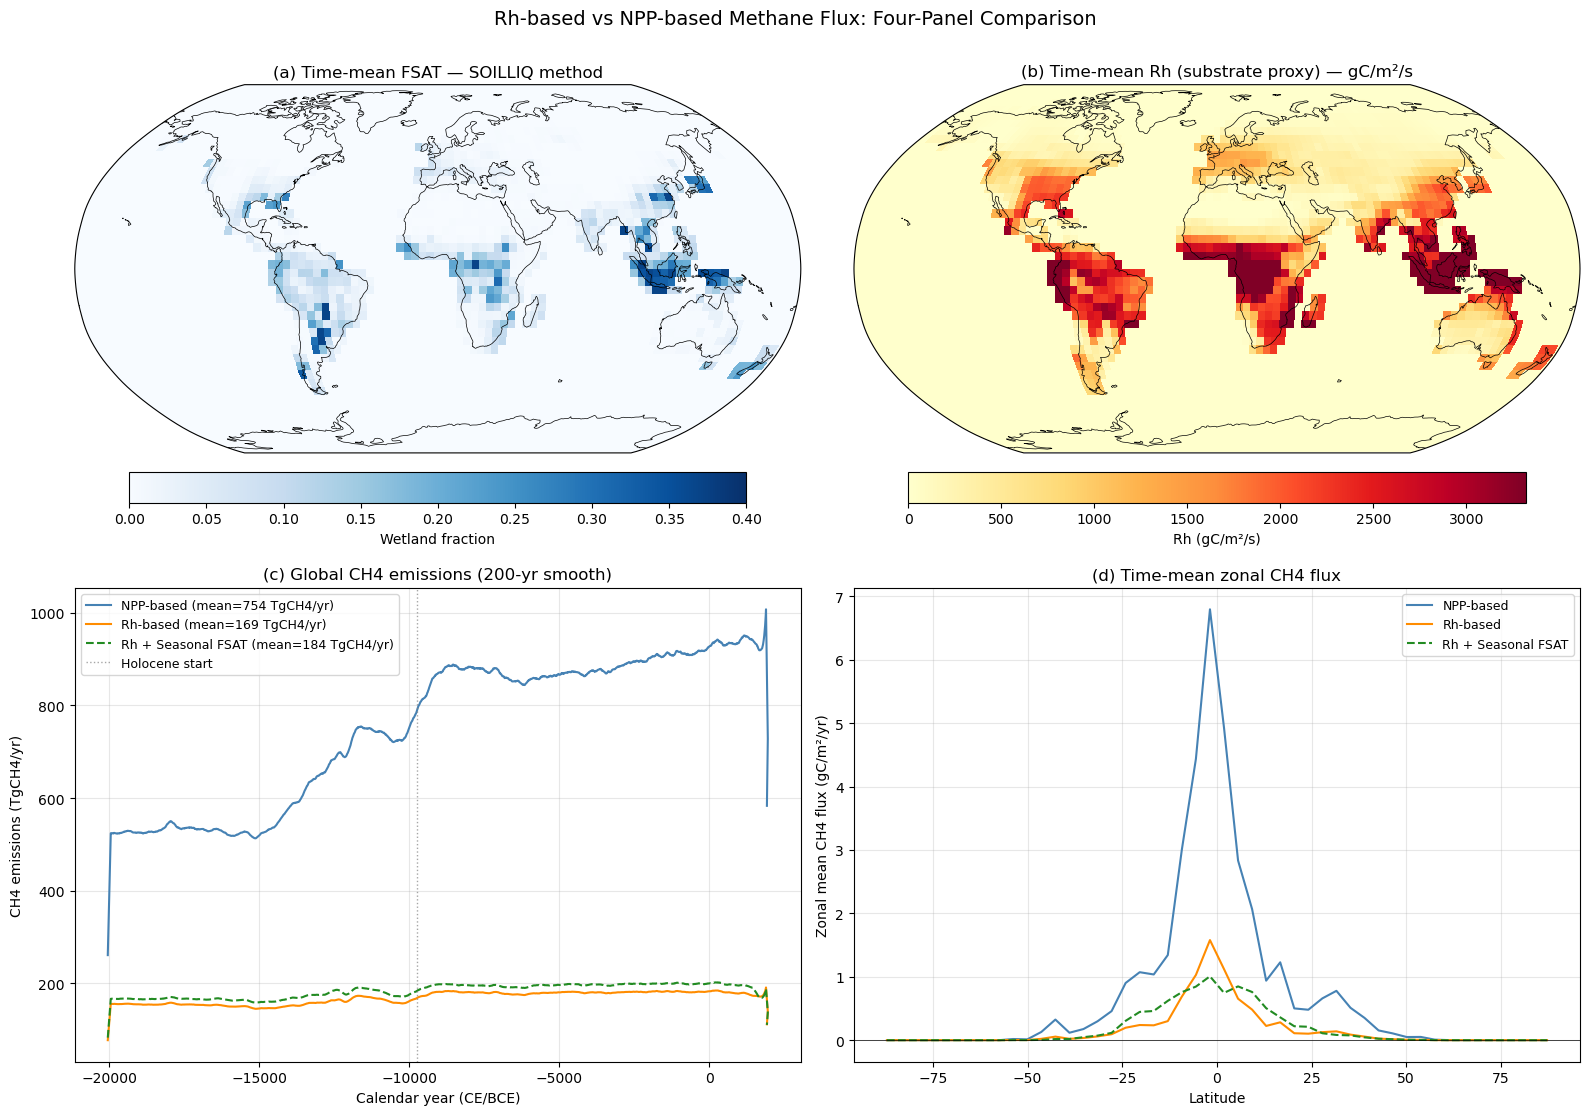

Saved: comparison_rh_vs_npp_4panel.png


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# Four-panel comparison plot: Rh-based vs NPP-based vs Seasonal FSAT schemes
# ══════════════════════════════════════════════════════════════════════════════

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Pre-compute time means in (lat, lon) for mapping
fsat_mean_soilliq = np.mean(fsat_soilliq, axis=2).T   # (lat, lon)
rh_mean_map_latlon = np.mean(rh_model, axis=2).T       # (lat, lon) - Rh for comparison

# Shift longitudes 0-360 → -180 to 180 for cartopy
lon_plot = np.where(lon > 180, lon - 360, lon)
sidx = np.argsort(lon_plot)
lon_s = lon_plot[sidx]
fsat_mean_soilliq_s = fsat_mean_soilliq[:, sidx]

# Time-mean CH4 flux maps for zonal calculation
f_ch4_mean_npp = np.nanmean(f_ch4_npp_baseline, axis=2).T  # (lat, lon)
f_ch4_mean_rh  = np.nanmean(f_ch4_rh, axis=2).T            # (lat, lon)
f_ch4_mean_seas = np.nanmean(f_ch4_rh_seas, axis=2).T      # (lat, lon)

# Zonal means
zonal_npp  = np.nanmean(f_ch4_mean_npp,  axis=1)   # (lat,)
zonal_rh   = np.nanmean(f_ch4_mean_rh,   axis=1)
zonal_seas = np.nanmean(f_ch4_mean_seas, axis=1)

# Smoothing helper
def smooth20(ts):
    return np.convolve(ts, np.ones(20)/20, mode='same')

proj = ccrs.Robinson()
pc   = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 11))
fig.suptitle('Rh-based vs NPP-based Methane Flux: Four-Panel Comparison', fontsize=14, y=1.01)

# ── Panel A: FSAT map – SOILLIQ method ──────────────────────────────────────
ax1 = fig.add_subplot(2, 2, 1, projection=proj)
im1 = ax1.pcolormesh(lon_s, lat, fsat_mean_soilliq_s,
                     transform=pc, cmap='Blues', vmin=0, vmax=0.4, shading='auto')
ax1.coastlines(linewidth=0.5)
ax1.set_global()
ax1.set_title('(a) Time-mean FSAT — SOILLIQ method')
plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.04, shrink=0.85,
             label='Wetland fraction')

# ── Panel B: Rh map (time-mean substrate proxy) ─────────────────────────────
ax2 = fig.add_subplot(2, 2, 2, projection=proj)
rh_map_s = rh_mean_map_latlon[:, sidx]
vmax_rh_map = np.nanpercentile(rh_map_s[~np.isnan(rh_map_s)], 98) if np.any(np.isfinite(rh_map_s)) else 1
im2 = ax2.pcolormesh(lon_s, lat, rh_map_s,
                     transform=pc, cmap='YlOrRd', vmin=0, vmax=vmax_rh_map, shading='auto')
ax2.coastlines(linewidth=0.5)
ax2.set_global()
ax2.set_title('(b) Time-mean Rh (substrate proxy) — gC/m²/s')
plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.04, shrink=0.85,
             label='Rh (gC/m²/s)')

# ── Panel C: Global CH4 emissions time series ────────────────────────────────
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(years_ce, smooth20(em_npp_baseline), color='steelblue', lw=1.5, 
         label=f'NPP-based (mean={em_npp_baseline.mean():.0f} TgCH4/yr)')
ax3.plot(years_ce, smooth20(em_rh), color='darkorange', lw=1.5, 
         label=f'Rh-based (mean={em_rh.mean():.0f} TgCH4/yr)')
ax3.plot(years_ce, smooth20(em_rh_seas), color='forestgreen', lw=1.5, ls='--',
         label=f'Rh + Seasonal FSAT (mean={em_rh_seas.mean():.0f} TgCH4/yr)')
ax3.axvline(years_ce[h0], color='gray', lw=1, ls=':', alpha=0.7, label='Holocene start')
ax3.set_xlabel('Calendar year (CE/BCE)')
ax3.set_ylabel('CH4 emissions (TgCH4/yr)')
ax3.set_title('(c) Global CH4 emissions (200-yr smooth)')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# ── Panel D: Zonal mean CH4 flux ─────────────────────────────────────────────
ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(lat, zonal_npp,  color='steelblue',  lw=1.5, label='NPP-based')
ax4.plot(lat, zonal_rh,   color='darkorange', lw=1.5, label='Rh-based')
ax4.plot(lat, zonal_seas, color='forestgreen', lw=1.5, ls='--', label='Rh + Seasonal FSAT')
ax4.axhline(0, color='k', lw=0.5)
ax4.set_xlabel('Latitude')
ax4.set_ylabel('Zonal mean CH4 flux (gC/m²/yr)')
ax4.set_title('(d) Time-mean zonal CH4 flux')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_rh_vs_npp_4panel.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comparison_rh_vs_npp_4panel.png')

/Users/huangyu/miniconda3/envs/mphil/lib/python3.10/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/huangyu/miniconda3/envs/mphil/lib/python3.10/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/huangyu/miniconda3/envs/mphil/lib/python3.10/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/huangyu/miniconda3/envs/mphil/lib/python3.10/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/huangyu/miniconda3/envs/mphil/lib/python3.10/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


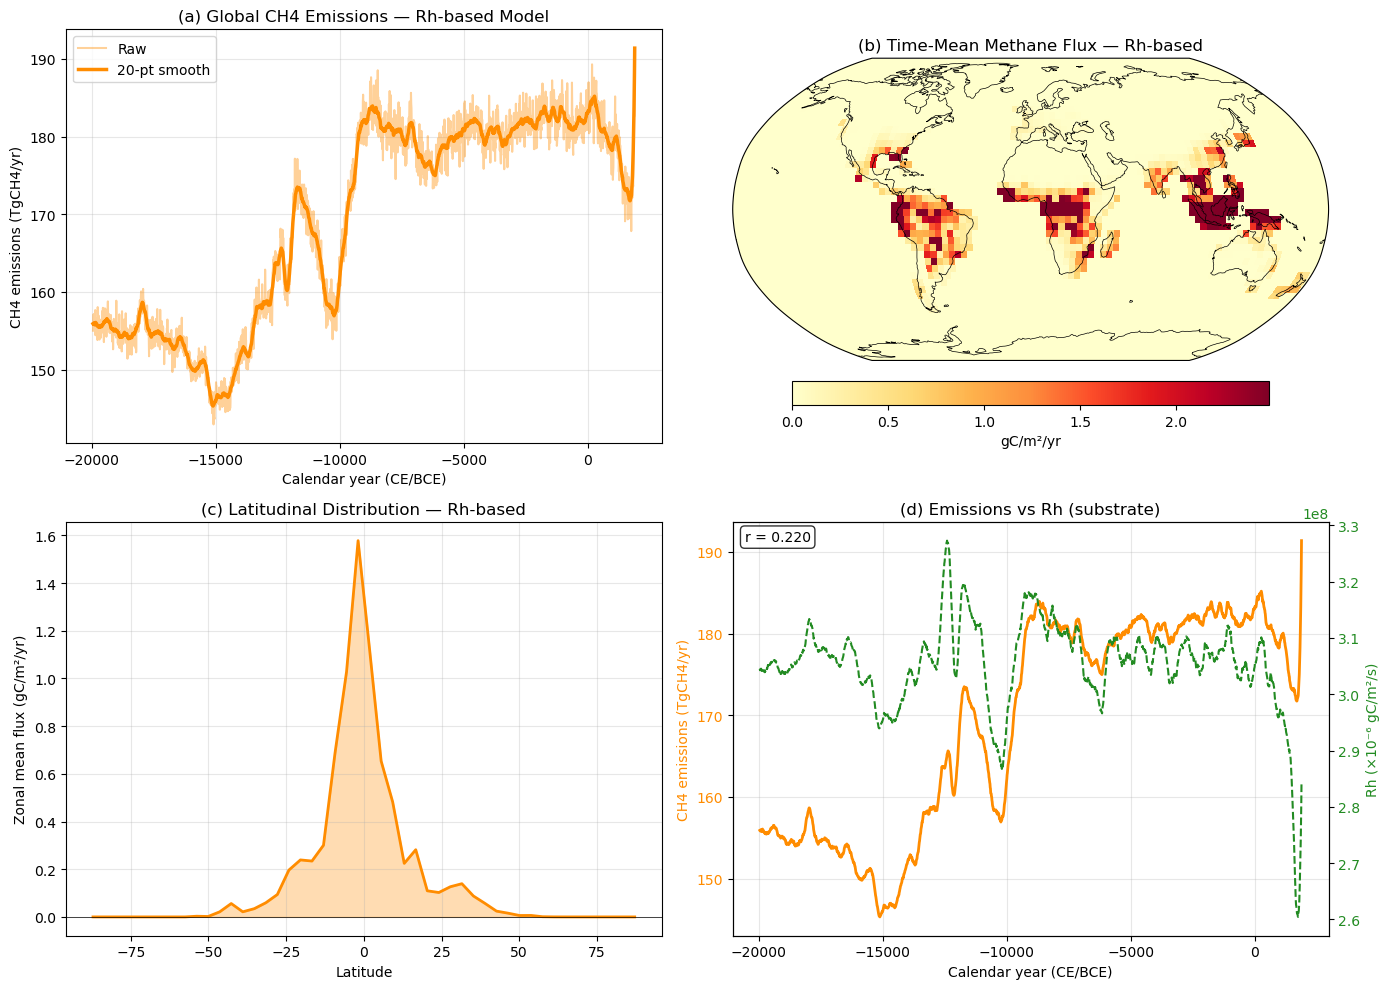

Saved: rh_methane_model_4panel.png


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# Four-panel summary: Rh-based Methane Model (style from 20260219 notebook)
# ══════════════════════════════════════════════════════════════════════════════

import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(14, 10))

# ── Panel 1: Time series (calendar years) ────────────────────────────────────
ax = fig.add_subplot(2, 2, 1)

# Smooth with 20-point running mean, trim edges to avoid artifacts
win = 20
em_rh_smooth = np.convolve(em_rh, np.ones(win)/win, mode='valid')
years_trim = years_ce[win//2 : -(win//2-1)]  # Trim years to match smoothed length

ax.plot(years_trim, em_rh[win//2 : -(win//2-1)], 'darkorange', linewidth=1.5, alpha=0.4, label='Raw')
ax.plot(years_trim, em_rh_smooth, 'darkorange', linewidth=2.5, label='20-pt smooth')
ax.set_xlabel('Calendar year (CE/BCE)')
ax.set_ylabel('CH4 emissions (TgCH4/yr)')
ax.set_title('(a) Global CH4 Emissions — Rh-based Model')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')

# ── Panel 2: Mean spatial pattern (Robinson projection) ─────────────────────
ax = fig.add_subplot(2, 2, 2, projection=ccrs.Robinson())
f_ch4_rh_mean = np.nanmean(f_ch4_rh, axis=2)  # (lon, lat) average over time

# Convert longitude from 0-360 to -180 to 180 for proper plotting
lon_plot = np.where(lon > 180, lon - 360, lon)
sort_idx = np.argsort(lon_plot)
lon_sorted = lon_plot[sort_idx]
f_ch4_sorted = f_ch4_rh_mean[sort_idx, :]

# Create meshgrid for pcolormesh
lon_mesh, lat_mesh = np.meshgrid(lon_sorted, lat)

vmax = np.nanpercentile(f_ch4_sorted, 98)
im = ax.pcolormesh(lon_mesh, lat_mesh, f_ch4_sorted.T, 
                   transform=ccrs.PlateCarree(), 
                   cmap='YlOrRd', vmin=0, vmax=vmax, shading='auto')
ax.coastlines(linewidth=0.5)
ax.set_global()
ax.set_title('(b) Time-Mean Methane Flux — Rh-based')
cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
cbar.set_label('gC/m²/yr')

# ── Panel 3: Latitudinal distribution ────────────────────────────────────────
ax = fig.add_subplot(2, 2, 3)
f_ch4_zonal = np.nanmean(f_ch4_rh_mean, axis=0)  # Zonal mean (lat,)
ax.plot(lat, f_ch4_zonal, 'darkorange', linewidth=2)
ax.fill_between(lat, 0, f_ch4_zonal, alpha=0.3, color='darkorange')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Latitude')
ax.set_ylabel('Zonal mean flux (gC/m²/yr)')
ax.set_title('(c) Latitudinal Distribution — Rh-based')
ax.grid(True, alpha=0.3)

# ── Panel 4: Emissions vs Rh (substrate) ─────────────────────────────────────
ax = fig.add_subplot(2, 2, 4)
rh_global = np.nanmean(rh_model, axis=(0, 1))
rh_global_smooth = np.convolve(rh_global, np.ones(win)/win, mode='valid')
ax2 = ax.twinx()
ax.plot(years_trim, em_rh_smooth, 'darkorange', linewidth=2, label='CH4 emissions')
ax2.plot(years_trim, rh_global_smooth * 1e6, 'forestgreen', linewidth=1.5, ls='--', label='Global mean Rh')
ax.set_xlabel('Calendar year (CE/BCE)')
ax.set_ylabel('CH4 emissions (TgCH4/yr)', color='darkorange')
ax2.set_ylabel('Rh (×10⁻⁶ gC/m²/s)', color='forestgreen')
ax.set_title('(d) Emissions vs Rh (substrate)')
ax.tick_params(axis='y', labelcolor='darkorange')
ax2.tick_params(axis='y', labelcolor='forestgreen')
ax.grid(True, alpha=0.3)

# Correlation (use trimmed data)
r_corr = np.corrcoef(em_rh_smooth, rh_global_smooth)[0, 1]
ax.text(0.02, 0.98, f'r = {r_corr:.3f}', transform=ax.transAxes, 
        fontsize=10, va='top', ha='left', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('rh_methane_model_4panel.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: rh_methane_model_4panel.png')

Read [](file:///Users/huangyu/phd/trace/20260302_yu_rh_methane.ipynb#51-51), lines 51 to 210

Here is the complete mathematical formulation of the current modelling approach:

---

## Offline Wetland CH₄ Model — Full Mathematical Formulation

### 1. Substrate: Detrended NPP as Rh Proxy

Since CLM2 Rh output is all-zero, NPP is detrended using a 1000-yr Gaussian filter to suppress the CO₂ fertilisation trend:

$$\widetilde{\text{NPP}}(\mathbf{x}, t) = \text{NPP}(\mathbf{x}, t) - \underbrace{G_\sigma * \text{NPP}(\mathbf{x}, t)}_{\text{low-freq trend}} + \overline{\text{NPP}}(\mathbf{x})$$

where $G_\sigma$ is a Gaussian kernel with $\sigma = 1000\ \text{yr}$ and $\overline{\text{NPP}}(\mathbf{x})$ is the time mean at each grid cell. This defines the substrate proxy $R_h(\mathbf{x}, t) = \max(\widetilde{\text{NPP}},\ 0)$.

---

### 2. Soil Temperature: Depth-Weighted Top 4 Layers

$$T_s(\mathbf{x}, t) = \frac{\sum_{k=1}^{4} T_{\text{soil},k}(\mathbf{x},t)\, \Delta z_k}{\sum_{k=1}^{4} \Delta z_k}$$

where $\Delta z_k$ are the CLM2 layer thicknesses for the top $\sim$12 cm.

---

### 3. Wetland Fraction: Sigmoid on Soil Liquid Saturation

Depth-weighted degree of saturation for the same top 4 layers:

$$\theta(\mathbf{x}, t) = \frac{\sum_{k=1}^{4} \theta_k(\mathbf{x},t)\, \Delta z_k}{\sum_{k=1}^{4} \Delta z_k}, \qquad \theta_k = \frac{\text{SOILLIQ}_k}{\theta_{\text{sat},k}\, \Delta z_k \times 1000}$$

Wetland fraction via sigmoid:

$$F_{\text{SAT}}(\mathbf{x}, t) = \frac{F_{\max}}{1 + e^{-k\,(\theta(\mathbf{x},t) - \theta_c)}}$$

with $F_{\max} = 0.4$, $\theta_c = 0.75$, $k = 10$.

---

### 4. Methane Flux

$$F_{\text{CH}_4}(\mathbf{x}, t) = F_{\text{SAT}}(\mathbf{x},t) \cdot K_{\text{Rh}} \cdot R_h(\mathbf{x},t) \cdot Q_{10}^{(T_s(\mathbf{x},t) - T_{\text{ref}})/10}$$

with $Q_{10} = 2.0$, $T_{\text{ref}} = 273.16\ \text{K}$ (Riley et al. 2011 parameters).

---

### 5. Global Emissions

$$E(t) = \sum_{\mathbf{x}} F_{\text{CH}_4}(\mathbf{x}, t)\cdot A(\mathbf{x}) \cdot \frac{16}{12} \cdot 10^{-12}\ \quad [\text{TgCH}_4\ \text{yr}^{-1}]$$

where $A(\mathbf{x})$ is the grid cell area in m².

---

### 6. Calibration

$K_{\text{Rh}}$ is determined by requiring the pre-industrial mean emission (last 50 timesteps, ~500–400 BCE) to equal the observational target $E_{\text{target}} = 180\ \text{TgCH}_4\ \text{yr}^{-1}$ (Saunois et al. 2020):

$$K_{\text{Rh}} = \frac{E_{\text{target}}}{\langle E(t)\rangle_{t \in \text{PI}}\big|_{K_{\text{Rh}}=1}}$$

## Justification: Detrended NPP as a Proxy for Heterotrophic Respiration (Rh)

### Motivation
The TraCE-21ka CLM2 simulation did not archive heterotrophic respiration (Rh) output. We therefore require a proxy for the organic substrate available for methanogenesis in wetland soils.

### Theoretical Basis

**1. NPP–Rh Coupling on Long Timescales**

On centennial-to-millennial timescales, ecosystem carbon balance approaches quasi-equilibrium, such that heterotrophic respiration (Rh) tracks net primary production (NPP):

$$\text{Rh} \approx \text{NPP} - \Delta C_{\text{soil}}$$

When soil carbon pools are near steady state ($\Delta C_{\text{soil}} \to 0$), we have $\text{Rh} \approx \text{NPP}$. This relationship is well-established in biogeochemistry (e.g., Schimel et al. 1994; Ciais et al. 2013).

**2. The Problem: CO₂ Fertilization in CLM**

CLM's NPP includes a strong CO₂ fertilization effect: as atmospheric CO₂ rises from ~180 ppm (LGM) to ~280 ppm (pre-industrial), photosynthesis increases even without climate change. In the TraCE simulation, this produces a +40% increase in global NPP through the deglaciation, which would *increase* modeled CH₄ emissions—opposite to the observed early Holocene CH₄ decline.

However, the CO₂ fertilization effect on NPP is *not* expected to proportionally increase methanogenic substrate because:
- Enhanced photosynthesis produces more labile carbon initially, but this is rapidly respired
- Long-term soil carbon accumulation under elevated CO₂ is limited by nutrient constraints (N, P)
- The *quality* of substrate for methanogenesis depends more on hydrology and temperature than total NPP

**3. Detrending Approach**

We remove the long-term trend (linear or low-frequency) from NPP to isolate:
- **Climate-driven variability**: Temperature, precipitation, and orbital forcing effects on vegetation productivity
- **Regional patterns**: Monsoon dynamics, boreal expansion/contraction, wetland extent changes

This detrended NPP serves as a proxy for Rh that responds to:
- Glacial–interglacial temperature changes (Q₁₀ effect on decomposition)
- Hydrological changes (monsoon intensity, wetland extent)
- Vegetation redistribution (biome shifts)

**4. What Detrending Preserves vs. Removes**

| Preserved | Removed |
|-----------|---------|
| Orbital-driven monsoon variability | CO₂ fertilization trend |
| Deglacial warming effect on decomposition | Secular NPP increase |
| Regional climate patterns (AHP, Asian monsoon) | Model-dependent CO₂ sensitivity |
| Interannual-to-millennial variability | Long-term disequilibrium effects |

### Caveats

1. **Lag effects**: True Rh lags NPP due to soil carbon turnover times (decades–centuries). Our approach assumes these lags average out on the glacial–interglacial timescale.

2. **Temperature sensitivity**: We apply a separate Q₁₀ correction, so detrended NPP primarily captures the *substrate availability* component.

3. **Regional heterogeneity**: The relationship between NPP and Rh varies by biome and soil type; our global approach may miss regional nuances.

### References

- Schimel, D.S., et al. (1994). Climatic, edaphic, and biotic controls over storage and turnover of carbon in soils. *Global Biogeochem. Cycles*, 8(3), 279–293.
- Ciais, P., et al. (2013). Carbon and Other Biogeochemical Cycles. In *Climate Change 2013: The Physical Science Basis* (IPCC AR5 WG1).
- Singarayer, J.S., & Valdes, P.J. (2010). High-latitude controls on low-latitude methane variations during glacial cycles. *Nature*, 463, 1127–1130.